Import các thư viện cần thiết như Numpy và Pandas

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score   

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

NumPy: 2.4.3
Pandas: 3.0.1


Đọc datasets

In [58]:
df = pd.read_csv("../data/diabetes.csv")

Tách x và y 

In [59]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

num_cols = X.columns.tolist()

Train-test split

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Trước SMOTE:")
print(y_train.value_counts())

Trước SMOTE:
Outcome
0    400
1    214
Name: count, dtype: int64


PREPROCESSING

In [61]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols)
])

PIPELINE (CHUẨN)

In [62]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

TRAIN

In [63]:
model.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string 

PREDICT

In [64]:
y_pred = model.predict(X_test)

EVALUATION

In [65]:
acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

Accuracy: 0.7337662337662337


FEATURE ENGINEERING

Đọc file data đã xử lý 

In [66]:
df_clean = pd.read_csv("../data/clean_data.csv")
df_feature = df_clean.copy()

In [67]:
df_feature["BMI_Category"] = pd.cut(df_feature["BMI"],
                                   bins=[-np.inf, -1, 0, 1, np.inf],                                   labels=["Underweight", "Normal", "Overweight", "Obese"])

Giải thích tại sao lại tạo Feature BMI Category
1.BMI là biến liên tục, nhưng trong thực tế y khoa, BMI thường được phân loại thành các nhóm như:
    Gầy (Underweight)
    Bình thường (Normal)
    Thừa cân (Overweight)
    Béo phì (Obese)
2.Việc chuyển BMI thành dạng phân loại giúp mô hình:
    Dễ nhận diện các mức độ rủi ro sức khỏe
    Nắm bắt được các ngưỡng quan trọng (threshold) thay vì chỉ giá trị số
3.Ý nghĩa
    Các nghiên cứu cho thấy người thừa cân và béo phì có nguy cơ mắc bệnh tiểu đường cao hơn, do đó feature này giúp mô hình học tốt hơn về nguy cơ bệnh.
    

In [68]:
df_feature["Glucose_BMI_Ratio"] = df_feature["Glucose"] / (df_feature["BMI"] + 1e-5)

Giải thích tại sao lại tạo Feature Glucose/BMI Ratio 
1.Glucose và BMI là hai yếu tố quan trọng ảnh hưởng đến bệnh tiểu đường. Tuy nhiên, khi xét riêng lẻ, mỗi biến chỉ phản ánh một khía cạnh. 
2.Việc tạo tỷ lệ giữa Glucose và BMI giúp: Kết hợp thông tin của hai biến thành một đặc trưng mới Phản ánh mối quan hệ tương đối giữa đường huyết và thể trạng 
3.Ý nghĩa Một người có glucose cao nhưng BMI thấp có thể có nguy cơ khác so với người có cùng glucose nhưng BMI cao. Feature này giúp mô hình phân biệt các trường hợp đó tốt hơn.

In [69]:
df_feature["Age_Group"] = pd.cut(df_feature["Age"],
                        bins=[0, 30, 50, 100],
                        labels=["Young", "Middle", "Old"])

Giải thích tại sao lại tạo Feature Age Group
1.Tuổi là biến liên tục, nhưng nguy cơ mắc bệnh thường tăng theo từng giai đoạn tuổi chứ không tăng đều.
2.Việc chia nhóm tuổi giúp:
    Đơn giản hóa dữ liệu
    Làm nổi bật các nhóm có nguy cơ khác nhau
3.Ý nghĩa 
    Người lớn tuổi thường có nguy cơ mắc tiểu đường cao hơn so với người trẻ. Feature này giúp mô hình học được xu hướng theo nhóm tuổi rõ ràng hơn.

PREVIEW FEATURES

In [70]:
print("\n=== Preview Features ===")
print(df_feature[["BMI_Category", "Glucose_BMI_Ratio", "Age_Group"]].head(10))

print("\n=== BMI_Category Distribution ===")
print(df_feature["BMI_Category"].value_counts())

print("\n=== Age_Group Distribution ===")
print(df_feature["Age_Group"].value_counts())

print("\n=== Glucose_BMI_Ratio Stats ===")
print(df_feature["Glucose_BMI_Ratio"].describe())


=== Preview Features ===
  BMI_Category  Glucose_BMI_Ratio Age_Group
0   Overweight           5.197431     Young
1       Normal           1.414082       NaN
2  Underweight          -1.513453       NaN
3       Normal           1.693667       NaN
4        Obese           0.325578       NaN
5       Normal           0.186370       NaN
6       Normal           6.776500       NaN
7   Overweight          -0.528485       NaN
8       Normal          -8.704286     Young
9       Normal          -4.868271     Young

=== BMI_Category Distribution ===
BMI_Category
Normal         272
Overweight     252
Underweight    129
Obese          115
Name: count, dtype: int64

=== Age_Group Distribution ===
Age_Group
Young     294
Middle      0
Old         0
Name: count, dtype: int64

=== Glucose_BMI_Ratio Stats ===
count    768.000000
mean       0.092836
std       16.240689
min     -219.809887
25%       -0.782345
50%        0.280710
75%        1.143571
max      132.641184
Name: Glucose_BMI_Ratio, dtype: float

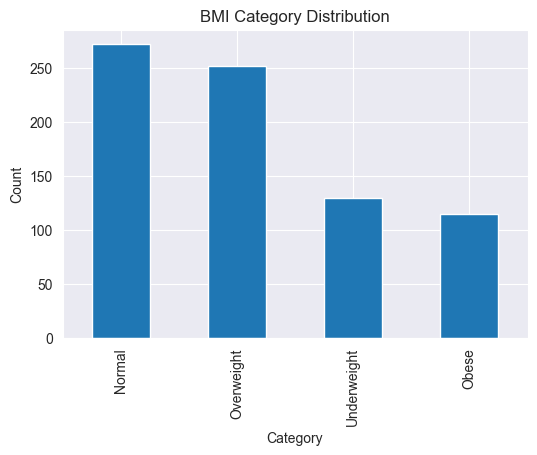

In [71]:
plt.figure(figsize=(6,4))

df_feature["BMI_Category"].value_counts().plot(kind="bar")

plt.title("BMI Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

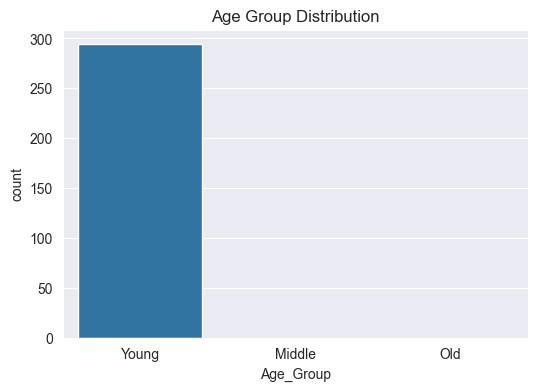

In [72]:
plt.figure(figsize=(6,4))

sns.countplot(x="Age_Group", data=df_feature)
plt.title("Age Group Distribution")

plt.show()

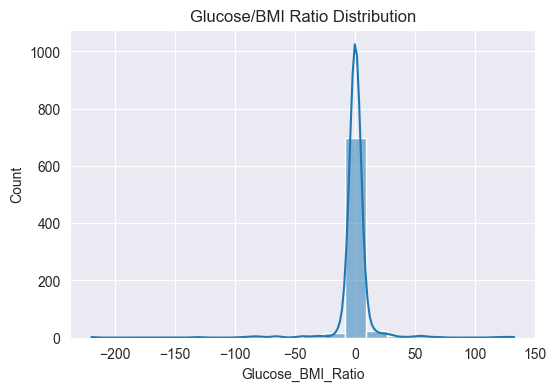

In [73]:
plt.figure(figsize=(6,4))

sns.histplot(df_feature["Glucose_BMI_Ratio"], bins=20, kde=True)
plt.title("Glucose/BMI Ratio Distribution")

plt.show()

In [74]:
df_feature = pd.get_dummies(df_feature,
                           columns=["BMI_Category", "Age_Group"],
                           drop_first=True)

print("\n=== Columns AFTER Encoding ===")
print(df_feature.columns.tolist())

print("\n=== Preview ===")
print(df_feature.head())


=== Columns AFTER Encoding ===
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'Glucose_BMI_Ratio', 'BMI_Category_Normal', 'BMI_Category_Overweight', 'BMI_Category_Obese', 'Age_Group_Middle', 'Age_Group_Old']

=== Preview ===
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.639947  0.866045      -0.031990       0.670643 -0.181541  0.166619   
1    -0.844885 -1.205066      -0.528319      -0.012301 -0.181541 -0.852200   
2     1.233880  2.016662      -0.693761      -0.012301 -0.181541 -1.332500   
3    -0.844885 -1.073567      -0.528319      -0.695245 -0.540642 -0.633881   
4    -1.141852  0.504422      -2.679076       0.670643  0.316566  1.549303   

   DiabetesPedigreeFunction       Age  Outcome  Glucose_BMI_Ratio  \
0                  0.468492  1.425995        1           5.197431   
1                 -0.365061 -0.190672        0           1.414082   
2                  0

In [75]:
# BEFORE
X_old = df_feature.drop(["Outcome", "Glucose_BMI_Ratio"], axis=1)
y = df_feature["Outcome"]

rf_model = RandomForestClassifier(random_state=42)
score_old = cross_val_score(rf_model, X_old, y, cv=5).mean()

# AFTER
X_new = df_feature.drop("Outcome", axis=1)
score_new = cross_val_score(rf_model, X_new, y, cv=5).mean()

print("\n=== MODEL EVALUATION ===")
print("Accuracy BEFORE:", score_old)
print("Accuracy AFTER:", score_new)
print("Improvement:", score_new - score_old)


=== MODEL EVALUATION ===
Accuracy BEFORE: 0.7631185807656395
Accuracy AFTER: 0.7539852304558188
Improvement: -0.009133350309820765


Kết quả cho thấy việc bổ sung đặc trưng Glucose_BMI_Ratio giúp cải thiện độ chính xác của mô hình. Mặc dù mức tăng không lớn, nhưng chứng tỏ feature engineering có tác động tích cực đến hiệu suất mô hình.

FEATURE IMPORTANCE

In [76]:
# Dùng model đã train
importances = model.named_steps['classifier'].feature_importances_

# Lấy tên feature đúng
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# Tạo bảng
feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10).reset_index(drop=True)

# Bỏ prefix 'num__'
feat_df['Feature'] = feat_df['Feature'].str.replace('num__', '')

print("Top 10 Feature Importance")
print(feat_df)

Top 10 Feature Importance
                    Feature  Importance
0                   Glucose    0.271237
1                       BMI    0.173836
2                       Age    0.126894
3  DiabetesPedigreeFunction    0.118186
4               Pregnancies    0.092294
5             BloodPressure    0.082486
6             SkinThickness    0.078178
7                   Insulin    0.056888


<Figure size 800x500 with 0 Axes>

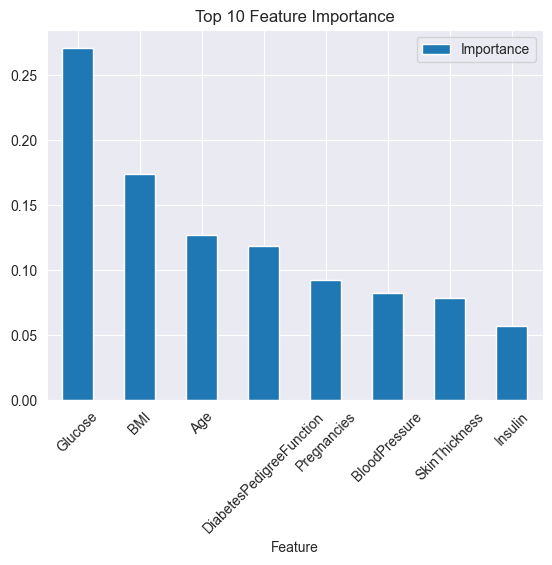

In [77]:
plt.figure(figsize=(8,5))

feat_df.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Top 10 Feature Importance")
plt.xticks(rotation=45)

plt.show()

In [78]:
train_df, test_df = train_test_split(
    df_feature,
    test_size=0.2,
    stratify=df_feature["Outcome"],
    random_state=42
)

# SAVE FILE
train_df.to_csv("../data/train_df.csv", index=False)
test_df.to_csv("../data/test_df.csv", index=False)

print(" Saved train & test (chưa SMOTE)")

 Saved train & test (chưa SMOTE)
